In [2]:
# now we want to combine these guys

In [3]:
import pandas as pd
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
import PSDProd as prod
import csvCleaner as cleaner

plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Sans'
# plt.rcParams['figure.figsize'] = (3,2)
# plt.rcParams["figure.dpi"] = 300

In [4]:
# set up globals, these will have prompts and such in the interactive
sampFreq = 100 #Hz
nper = 200
winHalfWidth = 5 # seconds
halfWIndex = winHalfWidth*sampFreq
voltCon = 5/16383

prod.defFreq = sampFreq
prod.defNper = nper
cleaner.sampFreq = sampFreq
cleaner.window_half_width = winHalfWidth
cleaner.halfWIndex = halfWIndex
cleaner.defVoltCon = voltCon

In [5]:
unoPath = '../SDCardOut/uno/concurrentUNO1.CSV'
dosPath = '../SDCardOut/dos/concurrentDOS1.CSV'
tresPath = '../SDCardOut/tres/concurrentTRES1.CSV'

unoNoMagPath = '../SDCardOut/uno/noMagFullUNO.CSV'
dosNoMagPath = '../SDCardOut/dos/noMagFullDOS.CSV'
tresNoMagPath = '../SDCardOut/tres/noMagFullTRES.CSV'

clickerPath = '../clickerFiles/04_12_26545-620.csv'

In [6]:
unoSecs,unoSens,unoVolt = cleaner.arrayExtract(unoPath)
dosSecs,dosSens,dosVolt = cleaner.arrayExtract(dosPath)
tresSecs,tresSens,tresVolt = cleaner.arrayExtract(tresPath)

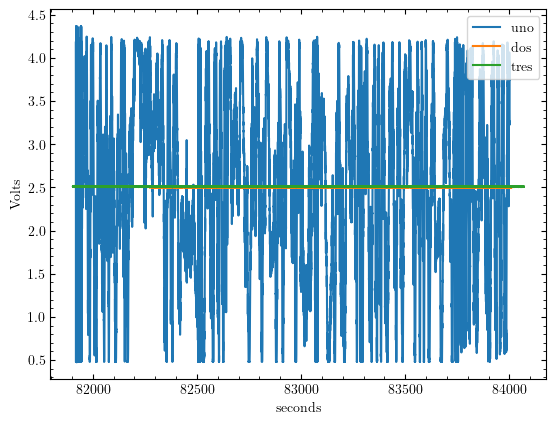

In [7]:
plt.plot(unoSecs,unoVolt,label='uno')
plt.plot(dosSecs,dosVolt,label='dos')
plt.plot(tresSecs,tresVolt,label='tres')
plt.legend()
plt.xlabel('seconds')
plt.ylabel('Volts')
# plt.tight_layout()
plt.show()

In [8]:
eventSecs = cleaner.utcSecondsConv(clickerPath)
eventSecs

array([82093.2, 82150.9, 82451.5, 82502.2, 82625.5, 83016.4, 83065.5,
       83239.5, 83278.6, 83689.2, 83736.1, 84055. ])

In [9]:
unoEventIdx = cleaner.eventIdx(unoSecs,eventSecs)
dosEventIdx = cleaner.eventIdx(dosSecs,eventSecs)
tresEventIdx = cleaner.eventIdx(tresSecs,eventSecs)

In [10]:
unoEventVolt,unoNoiseVolt = cleaner.windowMaker(unoVolt,unoEventIdx)
unoEventSecs,unoNoiseSecs = cleaner.windowMaker(unoSecs,unoEventIdx)

dosEventVolt,dosNoiseVolt = cleaner.windowMaker(dosVolt,dosEventIdx)
dosEventSecs,dosNoiseSecs = cleaner.windowMaker(dosSecs,dosEventIdx)

tresEventVolt,tresNoiseVolt = cleaner.windowMaker(tresVolt,tresEventIdx)
tresEventSecs,tresNoiseSecs = cleaner.windowMaker(tresSecs,tresEventIdx)

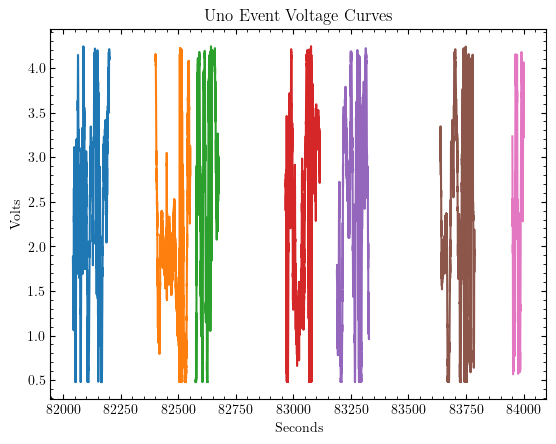

In [11]:
for i in range(len(unoEventVolt)):
    plt.plot(unoEventSecs[i],unoEventVolt[i])

plt.ylabel('Volts')
plt.xlabel('Seconds')
plt.title('Uno Event Voltage Curves')
plt.show()

In [12]:
unoEventVoltDown = prod.downSamp(unoEventVolt)
unoNoiseVoltDown = prod.downSamp(unoNoiseVolt)

dosEventVoltDown = prod.downSamp(dosEventVolt)
dosNoiseVoltDown = prod.downSamp(dosNoiseVolt)

tresEventVoltDown = prod.downSamp(tresEventVolt)
tresNoiseVoltDown = prod.downSamp(tresNoiseVolt)

In [13]:
unoEventPSDs,unoEventF = prod.makePSD(unoEventVoltDown)
unoNoisePSDs,unoNoiseF = prod.makePSD(unoNoiseVoltDown)

dosEventPSDs,dosEventF = prod.makePSD(dosEventVoltDown)
dosNoisePSDs,dosNoiseF = prod.makePSD(dosNoiseVoltDown)

tresEventPSDs,tresEventF = prod.makePSD(tresEventVoltDown)
tresNoisePSDs,tresNoiseF = prod.makePSD(tresNoiseVoltDown)

/Users/bkorotko03/Desktop/AL/ALTrainSeismo/analysisPipe/PSDProd.py:47: UserWarning: nperseg=200 is greater than signal length max(len(x), len(y)) = 115, using nperseg = 115
  fGrid,psd = welch(list[i],fs=freqDict[label],nperseg=defNper)
/Users/bkorotko03/Desktop/AL/ALTrainSeismo/analysisPipe/PSDProd.py:47: UserWarning: nperseg=200 is greater than signal length max(len(x), len(y)) = 116, using nperseg = 116
  fGrid,psd = welch(list[i],fs=freqDict[label],nperseg=defNper)


In [14]:
unoEventAvgPSD,unoEventAvgF = prod.PSDAverage(unoEventPSDs,unoEventF)
unoNoiseAvgPSD,unoNoiseAvgF = prod.PSDAverage(unoEventPSDs,unoEventF)

dosEventAvgPSD,dosEventAvgF = prod.PSDAverage(dosEventPSDs,dosEventF)
dosNoiseAvgPSD,dosNoiseAvgF = prod.PSDAverage(dosEventPSDs,dosEventF)

tresEventAvgPSD,tresEventAvgF = prod.PSDAverage(tresEventPSDs,tresEventF)
tresNoiseAvgPSD,tresNoiseAvgF = prod.PSDAverage(tresEventPSDs,tresEventF)

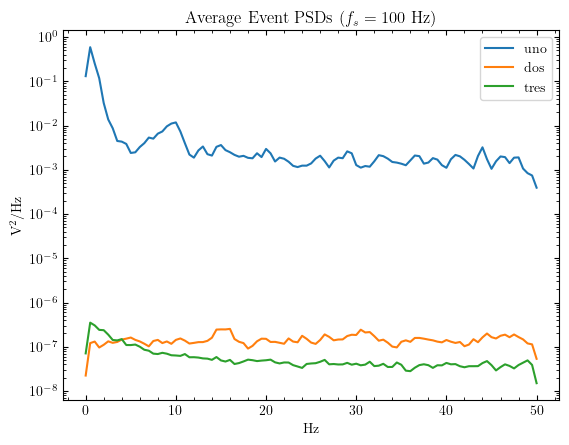

In [15]:
plt.plot(unoEventAvgF['freq100'],unoEventAvgPSD['freq100'],label='uno')
plt.plot(dosEventAvgF['freq100'],dosEventAvgPSD['freq100'],label='dos')
plt.plot(tresEventAvgF['freq100'],tresEventAvgPSD['freq100'],label='tres')

plt.semilogy()
plt.legend()
plt.xlabel('Hz')
plt.ylabel('V$^2$/Hz')
plt.title('Average Event PSDs ($f_s = 100$ Hz)')
plt.show()

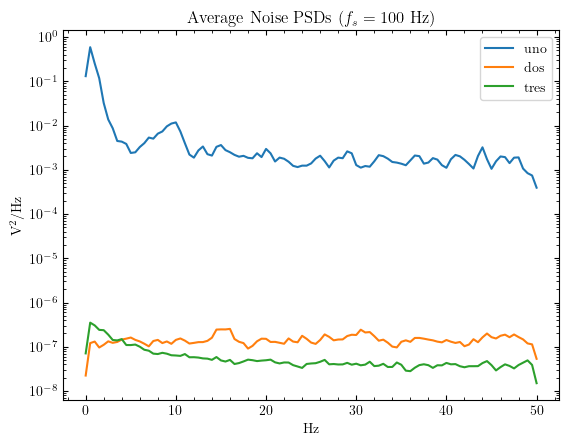

In [16]:
plt.plot(unoNoiseAvgF['freq100'],unoNoiseAvgPSD['freq100'],label='uno')
plt.plot(dosNoiseAvgF['freq100'],dosNoiseAvgPSD['freq100'],label='dos')
plt.plot(tresNoiseAvgF['freq100'],tresNoiseAvgPSD['freq100'],label='tres')

plt.semilogy()
plt.legend()
plt.xlabel('Hz')
plt.ylabel('V$^2$/Hz')
plt.title('Average Noise PSDs ($f_s = 100$ Hz)')
plt.show()

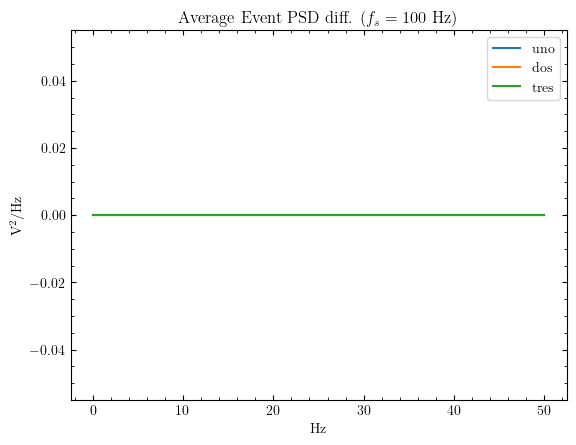

In [17]:
plt.plot(unoEventAvgF['freq100'],unoEventAvgPSD['freq100']-unoNoiseAvgPSD['freq100'],label='uno')
plt.plot(dosEventAvgF['freq100'],dosEventAvgPSD['freq100']-dosNoiseAvgPSD['freq100'],label='dos')
plt.plot(tresEventAvgF['freq100'],tresEventAvgPSD['freq100']-tresNoiseAvgPSD['freq100'],label='tres')

# plt.semilogy()
plt.legend()
plt.xlabel('Hz')
plt.ylabel('V$^2$/Hz')
plt.title('Average Event PSD diff. ($f_s = 100$ Hz)')
plt.show()

In [18]:
unoNoMagSecs,unoNoMagSens,unoNoMagVolt = cleaner.arrayExtract(unoNoMagPath)
dosNoMagSecs,dosNoMagSens,dosNoMagVolt = cleaner.arrayExtract(dosNoMagPath)
tresNoMagSecs,tresNoMagSens,tresNoMagVolt = cleaner.arrayExtract(tresNoMagPath)

In [19]:
unoNoMagF,unoNoMagPSD = welch(unoNoMagVolt,fs=sampFreq,nperseg=nper)

dosNoMagF,dosNoMagPSD = welch(dosNoMagVolt,fs=sampFreq,nperseg=nper)

tresNoMagF,tresNoMagPSD = welch(tresNoMagVolt,fs=sampFreq,nperseg=nper)

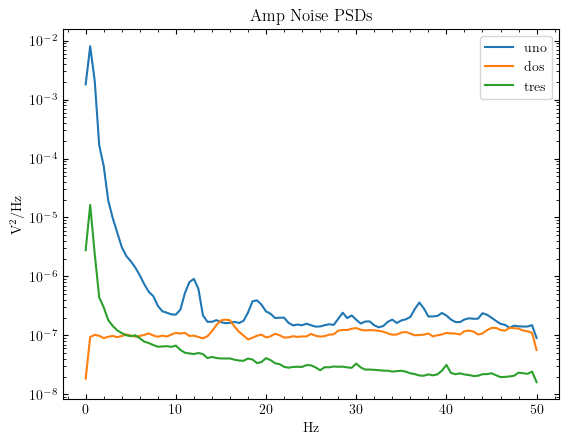

In [20]:
plt.plot(unoNoMagF,unoNoMagPSD,label='uno')
plt.plot(dosNoMagF,dosNoMagPSD,label='dos')
plt.plot(tresNoMagF,tresNoMagPSD,label='tres')

plt.semilogy()
plt.legend()
plt.xlabel('Hz')
plt.ylabel('V$^2$/Hz')
plt.title('Amp Noise PSDs')
plt.show()


In [21]:
unoNoisedB = prod.decibel(unoNoiseAvgPSD['freq100'],unoNoMagPSD)
dosNoisedB = prod.decibel(dosNoiseAvgPSD['freq100'],dosNoMagPSD)
tresNoisedB = prod.decibel(tresNoiseAvgPSD['freq100'],tresNoMagPSD)

unoTraindB = prod.decibel(unoEventAvgPSD['freq100'],unoNoiseAvgPSD['freq100'])
dosTraindB = prod.decibel(dosEventAvgPSD['freq100'],dosNoiseAvgPSD['freq100'])
tresTraindB = prod.decibel(tresEventAvgPSD['freq100'],tresNoiseAvgPSD['freq100'])

Text(0.5, 1.0, 'Avg Noise over Amp Noise')

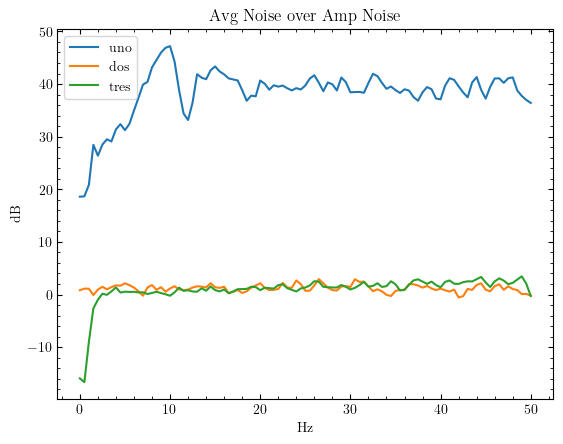

In [23]:
plt.plot(unoNoMagF,unoNoisedB,label='uno')
plt.plot(dosNoMagF,dosNoisedB,label='dos')
plt.plot(tresNoMagF,tresNoisedB,label='tres')

plt.xlabel('Hz')
plt.ylabel('dB')
plt.legend()
plt.title('Avg Noise over Amp Noise')

Text(0.5, 1.0, 'Avg Train Signal over Avg Noise')

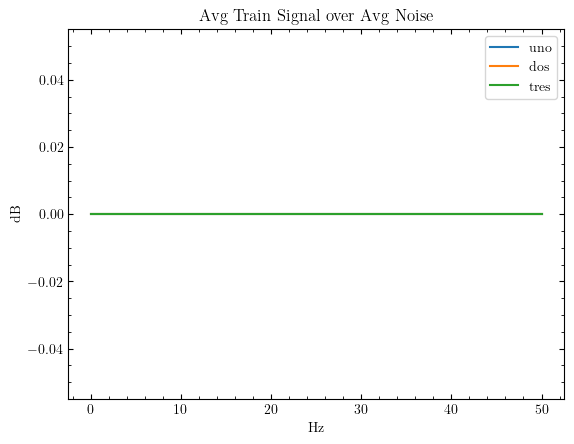

In [24]:
plt.plot(unoNoMagF,unoTraindB,label='uno')
plt.plot(dosNoMagF,dosTraindB,label='dos')
plt.plot(tresNoMagF,tresTraindB,label='tres')

plt.xlabel('Hz')
plt.ylabel('dB')
plt.legend()
plt.title('Avg Train Signal over Avg Noise')